# OpenSourcePulse — Time-Series Analysis

## Repository Activity Over Time

### Objective

Analyze the temporal evolution of repository activity using commit-level
timestamps collected over the recent 365-day observation window.

### Questions

1. How does aggregate repository activity change over time?
2. Which repositories show sustained activity?
3. Are activity patterns concentrated in particular periods?
4. How do repository activity trajectories differ?

### Methodology

1. Load the commit-level dataset.
2. Parse commit timestamps as UTC datetime values.
3. Remove duplicate repository-commit records.
4. Aggregate commits by calendar month.
5. Examine monthly activity trends.
6. Analyze repository-level activity trajectories.
7. Investigate activity consistency and concentration.

The analysis uses actual commit timestamps rather than repository metadata
timestamps such as `updated_at` or `pushed_at` as proxies for historical
activity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
commits = pd.read_csv(
    "../data/raw/repository_commits.csv"
)

print("Commit dataset shape:", commits.shape)
print()
print(commits.head())

Commit dataset shape: (381308, 13)

     repo_id                 full_name  \
0  196753133  artiebits/pdf-to-printer   
1  196753133  artiebits/pdf-to-printer   
2  196753133  artiebits/pdf-to-printer   
3  196753133  artiebits/pdf-to-printer   
4  196753133  artiebits/pdf-to-printer   

                                 commit_sha     author_login   author_id  \
0  2bb0fcb91c856466551fbba5fcbbb7b45dbd7426        artiebits  29281882.0   
1  7482ffe6d7240b53a0c457231826e9c1b5b487c7         sstopkin   5529180.0   
2  d1155b0a5b7ec8960a71bbd63bacc4eb212cd1af        artiebits  29281882.0   
3  eedd35e2e25adcf7c5c165f6a087d3a6b6092c95  dependabot[bot]  49699333.0   
4  340d42225b42301890841fe45851fbb63530a278  dependabot[bot]  49699333.0   

       author_name           author_date committer_login  committer_id  \
0        artiebits  2026-08-30T19:46:24Z       artiebits    29281882.0   
1   Stopkin Sergey  2026-08-30T19:35:12Z        web-flow    19864447.0   
2        artiebits  2026-04-25T0

In [3]:
commits["committer_date"] = pd.to_datetime(
    commits["committer_date"],
    utc=True,
    errors="coerce"
)

print("Missing committer dates:")
print(
    commits["committer_date"].isna().sum()
)

print()
print("Date range:")
print(
    commits["committer_date"].min(),
    "to",
    commits["committer_date"].max()
)

Missing committer dates:
0

Date range:
2025-09-18 14:37:03+00:00 to 2026-09-18 15:27:58+00:00


In [4]:
before = len(commits)

commits = commits.drop_duplicates(
    subset=["repo_id", "commit_sha"]
).copy()

after = len(commits)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal :", after)
print("Duplicates removed            :", before - after)

Rows before duplicate removal: 381308
Rows after duplicate removal : 381299
Duplicates removed            : 9


In [5]:
commits["month"] = (
    commits["committer_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_total = (
    commits
    .groupby("month")
    .agg(
        commits=("commit_sha", "nunique"),
        repositories=("repo_id", "nunique")
    )
    .reset_index()
)

monthly_total

C:\Users\hp\AppData\Local\Temp\ipykernel_12332\3690792560.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,month,commits,repositories
0,2025-09,8031,105
1,2025-10,20080,133
2,2025-11,22750,141
3,2025-12,20333,132
4,2026-01,31288,133
5,2026-02,28077,141
6,2026-03,36046,144
7,2026-04,40190,143
8,2026-05,43781,134
9,2026-06,32600,135


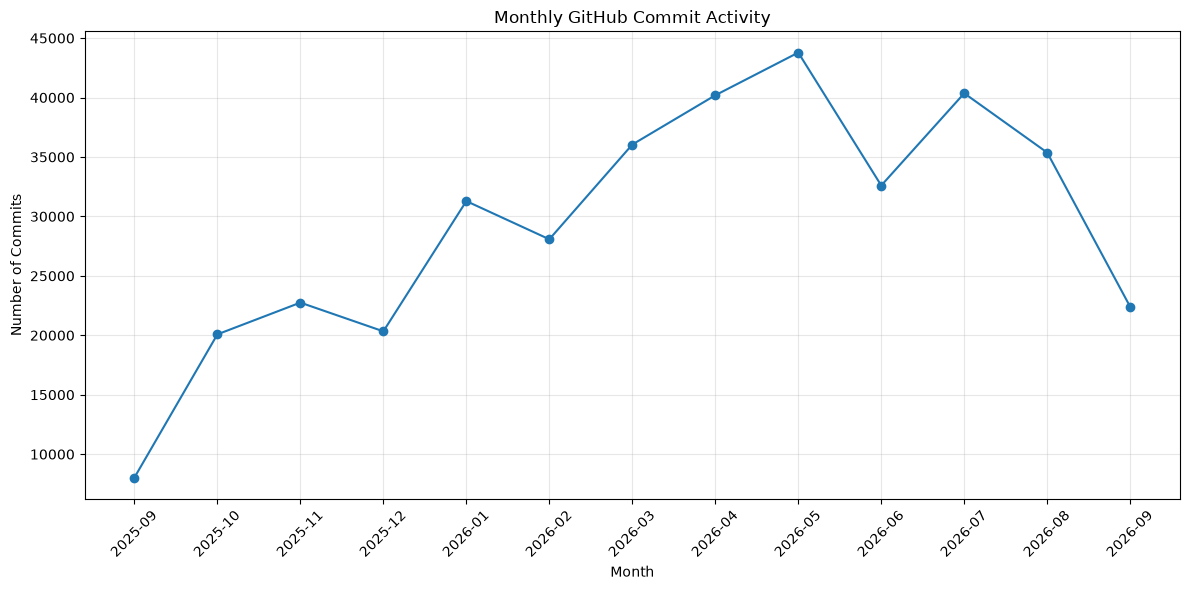

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_total["month"],
    monthly_total["commits"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Commits")
plt.title(
    "Monthly GitHub Commit Activity"
)

plt.xticks(
    rotation=45
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [7]:
monthly_total["mom_change"] = (
    monthly_total["commits"]
    .pct_change() * 100
)

monthly_total.round(2)

,month,commits,repositories,mom_change
0,2025-09,8031,105,NaN
1,2025-10,20080,133,150.03
2,2025-11,22750,141,13.30
3,2025-12,20333,132,-10.62
4,2026-01,31288,133,53.88
5,2026-02,28077,141,-10.26
6,2026-03,36046,144,28.38
7,2026-04,40190,143,11.50
8,2026-05,43781,134,8.94
9,2026-06,32600,135,-25.54


In [8]:
peak_row = monthly_total.loc[
    monthly_total["commits"].idxmax()
]

minimum_row = monthly_total.loc[
    monthly_total["commits"].idxmin()
]

print("Peak activity month")
print("-------------------")
print(
    peak_row[
        ["month", "commits", "repositories"]
    ]
)

print()
print("Minimum activity month")
print("----------------------")
print(
    minimum_row[
        ["month", "commits", "repositories"]
    ]
)

Peak activity month
-------------------
month           2026-05
commits           43781
repositories        134
Name: 8, dtype: object

Minimum activity month
----------------------
month           2025-09
commits            8031
repositories        105
Name: 0, dtype: object


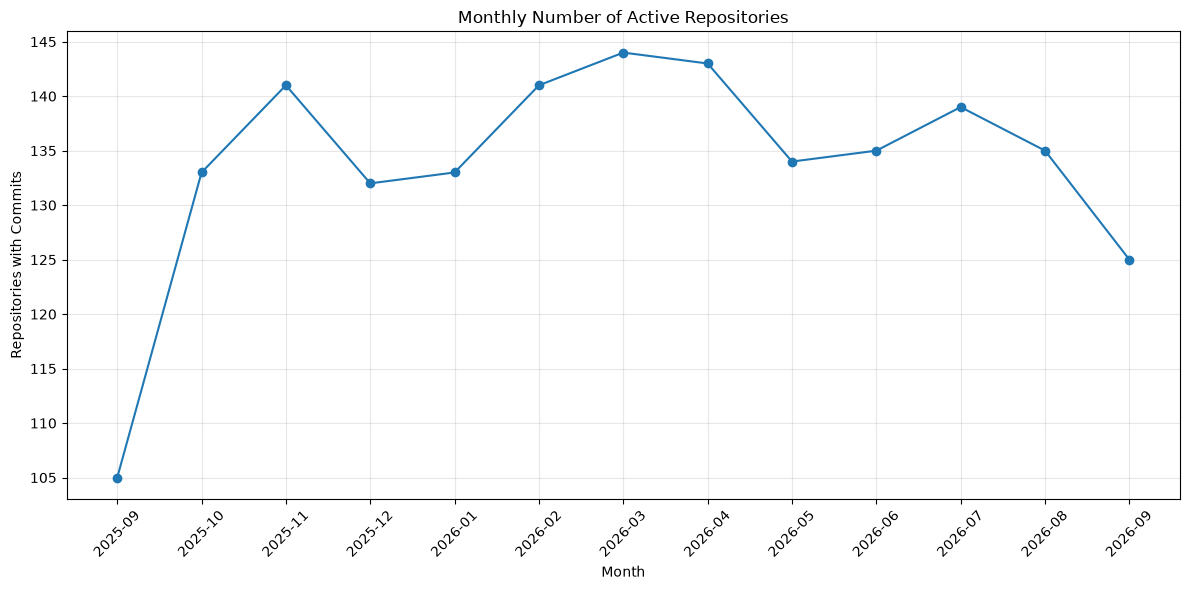

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_total["month"],
    monthly_total["repositories"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Repositories with Commits")
plt.title(
    "Monthly Number of Active Repositories"
)

plt.xticks(rotation=45)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [10]:
monthly_total["commits_per_active_repository"] = (
    monthly_total["commits"]
    / monthly_total["repositories"]
)

monthly_total.round(2)

,month,commits,repositories,mom_change,commits_per_active_repository
0,2025-09,8031,105,NaN,76.49
1,2025-10,20080,133,150.03,150.98
2,2025-11,22750,141,13.30,161.35
3,2025-12,20333,132,-10.62,154.04
4,2026-01,31288,133,53.88,235.25
5,2026-02,28077,141,-10.26,199.13
6,2026-03,36046,144,28.38,250.32
7,2026-04,40190,143,11.50,281.05
8,2026-05,43781,134,8.94,326.72
9,2026-06,32600,135,-25.54,241.48


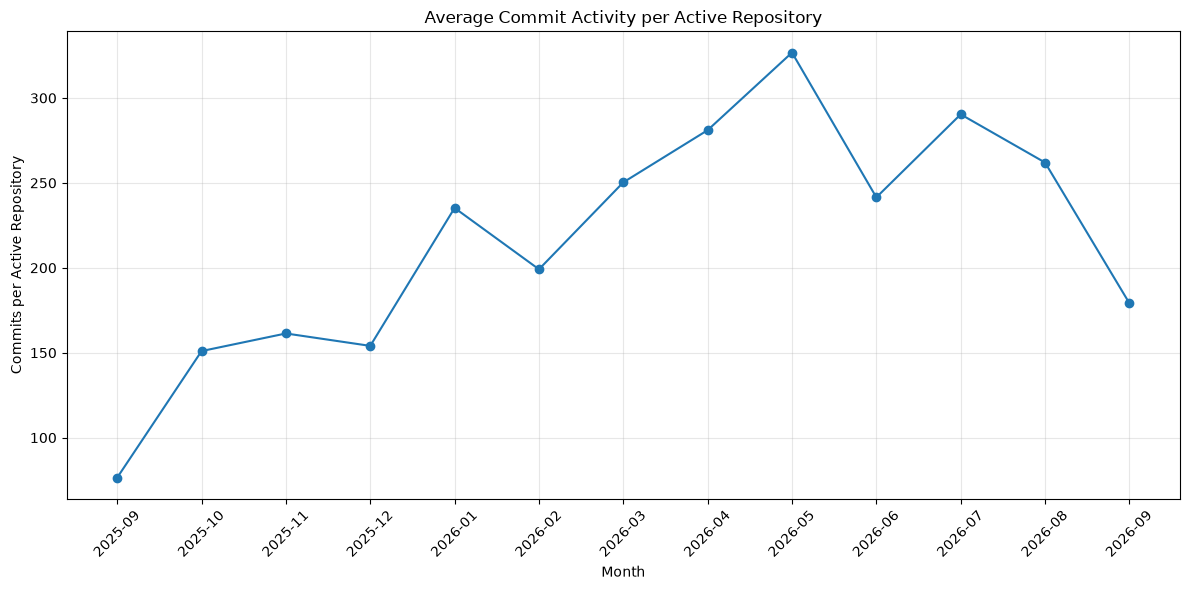

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_total["month"],
    monthly_total["commits_per_active_repository"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel(
    "Commits per Active Repository"
)

plt.title(
    "Average Commit Activity per Active Repository"
)

plt.xticks(rotation=45)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [12]:
repo_activity = (
    commits
    .groupby(
        ["repo_id", "full_name"]
    )
    .agg(
        commits_365d=(
            "commit_sha",
            "nunique"
        ),
        active_months=(
            "month",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "commits_365d",
        ascending=False
    )
)

repo_activity.head(20)

,repo_id,full_name,commits_365d,active_months
193,1103012935,openclaw/openclaw,96177,11
11,2325298,torvalds/linux,90201,13
64,41881900,microsoft/vscode,26590,13
184,975734319,anomalyco/opencode,13024,13
164,666299222,openinterpreter/openinterpreter,9498,13
34,15634981,godotengine/godot,9356,13
119,193215554,n8n-io/n8n,9055,13
118,192925833,prisma/orm,8256,12
161,643445235,lobehub/lobehub,7510,13
51,30203935,metabase/metabase,6755,13


In [13]:
activity_month_distribution = (
    repo_activity["active_months"]
    .value_counts()
    .sort_index()
)

activity_month_distribution

active_months
1     20
2     15
3     11
4     11
5     13
6      9
7     10
8     12
9      7
10     3
11    11
12    17
13    70
Name: count, dtype: int64

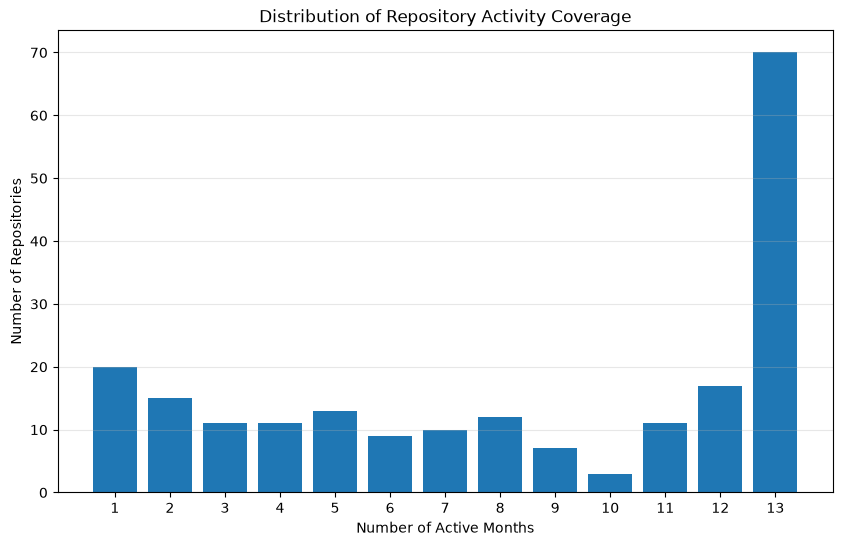

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    activity_month_distribution.index,
    activity_month_distribution.values
)

plt.xlabel(
    "Number of Active Months"
)

plt.ylabel(
    "Number of Repositories"
)

plt.title(
    "Distribution of Repository Activity Coverage"
)

plt.xticks(
    range(
        int(activity_month_distribution.index.min()),
        int(activity_month_distribution.index.max()) + 1
    )
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [15]:
top_repositories = (
    repo_activity
    .head(10)["full_name"]
    .tolist()
)

top_repositories

['openclaw/openclaw',
 'torvalds/linux',
 'microsoft/vscode',
 'anomalyco/opencode',
 'openinterpreter/openinterpreter',
 'godotengine/godot',
 'n8n-io/n8n',
 'prisma/orm',
 'lobehub/lobehub',
 'metabase/metabase']

In [19]:
top_monthly = (
    commits[
        commits["full_name"].isin(
            top_repositories
        )
    ]
    .groupby(
        ["full_name", "month"]
    )
    .agg(
        commits=(
            "commit_sha",
            "nunique"
        )
    )
    .reset_index()
)

# Convert month to a true chronological period
top_monthly["month_period"] = pd.PeriodIndex(
    top_monthly["month"],
    freq="M"
)

# Sort chronologically
top_monthly = (
    top_monthly
    .sort_values(
        ["full_name", "month_period"]
    )
    .reset_index(drop=True)
)

print("Top repository monthly activity:")
print(top_monthly.head(20))

Top repository monthly activity:
             full_name    month  commits month_period
0   anomalyco/opencode  2025-09      178      2025-09
1   anomalyco/opencode  2025-10      708      2025-10
2   anomalyco/opencode  2025-11     1050      2025-11
3   anomalyco/opencode  2025-12     1873      2025-12
4   anomalyco/opencode  2026-01     2080      2026-01
5   anomalyco/opencode  2026-02     1172      2026-02
6   anomalyco/opencode  2026-03      962      2026-03
7   anomalyco/opencode  2026-04     1306      2026-04
8   anomalyco/opencode  2026-05     1572      2026-05
9   anomalyco/opencode  2026-06     1049      2026-06
10  anomalyco/opencode  2026-07      594      2026-07
11  anomalyco/opencode  2026-08      346      2026-08
12  anomalyco/opencode  2026-09      134      2026-09
13   godotengine/godot  2025-09      395      2025-09
14   godotengine/godot  2025-10      940      2025-10
15   godotengine/godot  2025-11      984      2025-11
16   godotengine/godot  2025-12      882      202

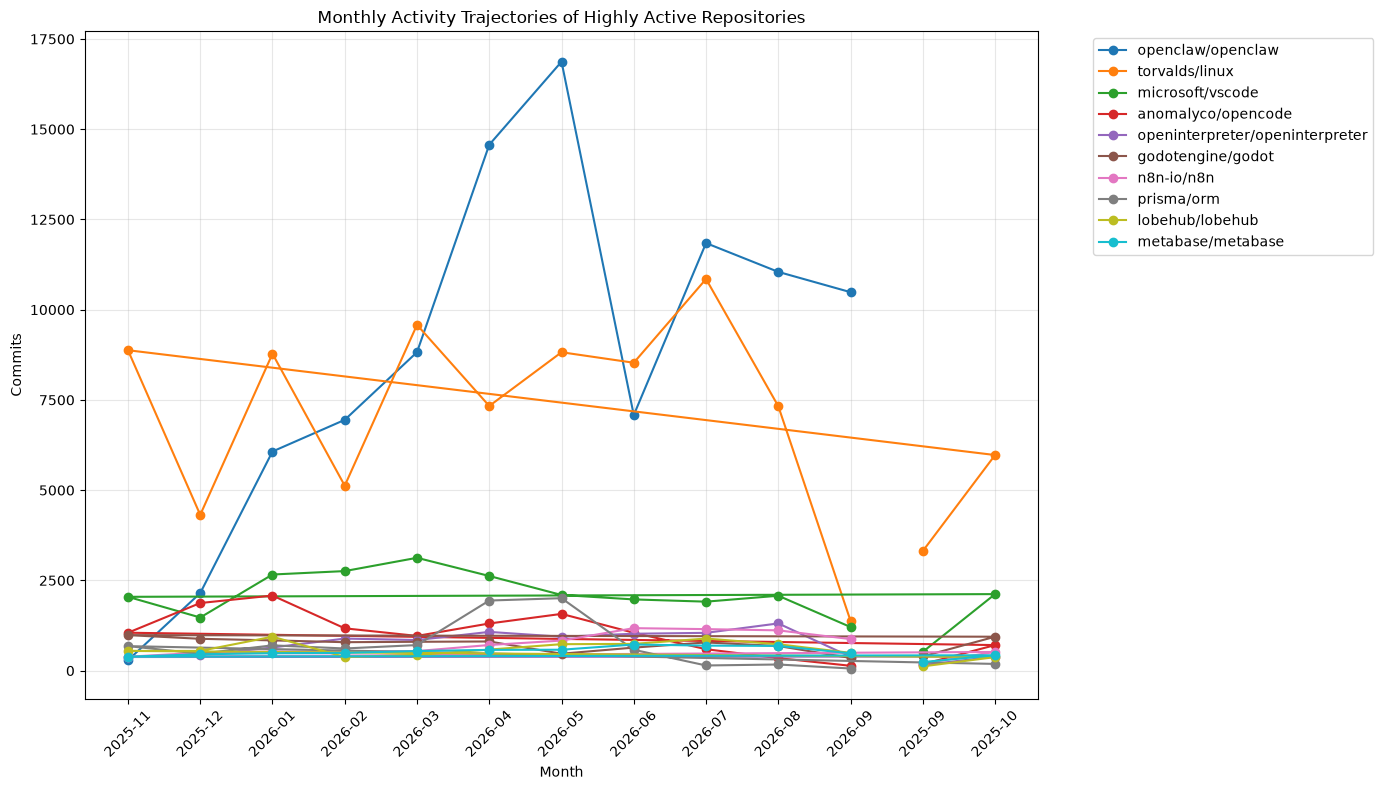

In [22]:
plt.figure(figsize=(14, 8))

for repo in top_repositories:

    subset = top_monthly[
        top_monthly["full_name"] == repo
    ].sort_values("month_period")

    plt.plot(
        subset["month_period"].astype(str),
        subset["commits"],
        marker="o",
        label=repo
    )

plt.xlabel("Month")
plt.ylabel("Commits")

plt.title(
    "Monthly Activity Trajectories of Highly Active Repositories"
)

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [23]:
monthly_total.to_csv(
    "../reports/monthly_activity_summary.csv",
    index=False
)

repo_activity.to_csv(
    "../reports/repository_activity_summary.csv",
    index=False
)

top_monthly.to_csv(
    "../reports/top_repository_monthly_activity.csv",
    index=False
)

print("Time-series analysis files saved successfully.")

Time-series analysis files saved successfully.


In [24]:
monthly_total.round(2)

,month,commits,repositories,mom_change,commits_per_active_repository
0,2025-09,8031,105,NaN,76.49
1,2025-10,20080,133,150.03,150.98
2,2025-11,22750,141,13.30,161.35
3,2025-12,20333,132,-10.62,154.04
4,2026-01,31288,133,53.88,235.25
5,2026-02,28077,141,-10.26,199.13
6,2026-03,36046,144,28.38,250.32
7,2026-04,40190,143,11.50,281.05
8,2026-05,43781,134,8.94,326.72
9,2026-06,32600,135,-25.54,241.48


In [25]:
peak_row = monthly_total.loc[
    monthly_total["commits"].idxmax()
]

minimum_row = monthly_total.loc[
    monthly_total["commits"].idxmin()
]

print("Peak activity month")
print("-------------------")
print(
    peak_row[
        ["month", "commits", "repositories"]
    ]
)

print()
print("Minimum activity month")
print("----------------------")
print(
    minimum_row[
        ["month", "commits", "repositories"]
    ]
)

Peak activity month
-------------------
month           2026-05
commits           43781
repositories        134
Name: 8, dtype: object

Minimum activity month
----------------------
month           2025-09
commits            8031
repositories        105
Name: 0, dtype: object


In [26]:
monthly_total["commits_per_active_repository"] = (
    monthly_total["commits"]
    / monthly_total["repositories"]
)

monthly_total.round(2)

,month,commits,repositories,mom_change,commits_per_active_repository
0,2025-09,8031,105,NaN,76.49
1,2025-10,20080,133,150.03,150.98
2,2025-11,22750,141,13.30,161.35
3,2025-12,20333,132,-10.62,154.04
4,2026-01,31288,133,53.88,235.25
5,2026-02,28077,141,-10.26,199.13
6,2026-03,36046,144,28.38,250.32
7,2026-04,40190,143,11.50,281.05
8,2026-05,43781,134,8.94,326.72
9,2026-06,32600,135,-25.54,241.48


In [27]:
repo_activity.head(20)
activity_month_distribution

active_months
1     20
2     15
3     11
4     11
5     13
6      9
7     10
8     12
9      7
10     3
11    11
12    17
13    70
Name: count, dtype: int64

In [28]:
repo_activity_sorted = repo_activity.sort_values(
    "commits_365d",
    ascending=False
).reset_index(drop=True)

total_commits = repo_activity_sorted[
    "commits_365d"
].sum()

for n in [5, 10, 20, 50]:

    top_n_commits = repo_activity_sorted.head(n)[
        "commits_365d"
    ].sum()

    share = (
        top_n_commits /
        total_commits *
        100
    )

    print(
        f"Top {n} repositories: "
        f"{top_n_commits:,} commits "
        f"({share:.2f}% of collected commits)"
    )

Top 5 repositories: 235,490 commits (61.76% of collected commits)
Top 10 repositories: 276,422 commits (72.49% of collected commits)
Top 20 repositories: 310,453 commits (81.42% of collected commits)
Top 50 repositories: 358,771 commits (94.09% of collected commits)


In [29]:
monthly_total.to_csv(
    "../reports/monthly_activity_summary.csv",
    index=False
)

repo_activity.to_csv(
    "../reports/repository_activity_summary.csv",
    index=False
)

top_monthly.to_csv(
    "../reports/top_repository_monthly_activity.csv",
    index=False
)

print("Time-series analysis files saved successfully.")

Time-series analysis files saved successfully.
